# Assignment 3: Text processing with LSTM in PyTorch

*Author:* Thomas Adler

*Copyright statement:* This  material,  no  matter  whether  in  printed  or  electronic  form,  may  be  used  for  personal  and non-commercial educational use only.  Any reproduction of this manuscript, no matter whether as a whole or in parts, no matter whether in printed or in electronic form, requires explicit prior acceptance of the authors.

In this assignment you will a train an LSTM to generate text. To be able to feed text into (recurrent) neural networks we first have to choose a good representation. There are several options to do so ranging from simple character embeddings to more sophisticated approaches like [word embeddings](https://towardsdatascience.com/introduction-to-word-embedding-and-word2vec-652d0c2060fa) or [token embeddings](https://medium.com/@_init_/why-bert-has-3-embedding-layers-and-their-implementation-details-9c261108e28a). We will use a character embedding in this assignment. 

Character embeddings work as follows. First we define an alphabet, a set of characters that we want to be able to represent. To feed a character into our network we use a one-hot vector. The dimension of this vector is equal to the size of our alphabet and the "hot" position indicates the character we want to represent. While this is logically a decent representation (all characters have the same norm, are orthogonal to one another, etc.) it is inefficient in terms of memory because we have to store a lot of zeros. In the first layer of our network we will multiply our one-hot vector with a weight matrix, i.e. we compute the preactivation by a matrix-vector product of the form $We_i$, where $e_i$ is the $i$-th canonical basis vector. This operation corresponds to selecting the $i$-th column of $W$. So an efficient implementation is to perform a simple lookup operation in $W$. This is how embedding layers work also for word or token embeddings. They are learnable lookup tables. 

## Exercise 1: Encoding characters

Write a class `Encoder` that implements the methods `__init__` and `__call__`. The method `__init__` takes a string as argument that serves as alphabet. The method `__call__` takes one argument. If it is a string then it should return a sequence of integers as `torch.Tensor` of shape  representing the input string. Each integer should represents a character of the alphabet. The alphabet consists of the characters matched by the regex `[a-z0-9 .!?]`. If the input text contains characters that are not in the alphabet, then `__call__` should either remove them or map them to a corresponding character that belongs to the alphabet. If the argument is a `torch.Tensor`, then the method should return a string representation of the input, i.e. it should function as decoder. 

In [ ]:
import re
import torch

########## YOUR SOLUTION HERE ##########

class Encoder:
    """
    Der Encoder übersetzt zwischen Text (String) und Zahlen (Tensor) für das Modell.
    
    Funktionen:
    - Wenn Input ein String ist → wird zu einem Tensor aus Integer-Indizes encodiert.
    - Wenn Input ein Tensor ist → wird zu einem String decodiert.

    Dabei werden nur Zeichen aus dem angegebenen Alphabet verwendet.
    Alles andere wird entfernt.
    """

    def __init__(self, alphabet: str):
        """
        Initialisierung des Encoders.
        
        Parameter:
        - alphabet: Ein String mit allen erlaubten Zeichen, z.B.
          'abcdefghijklmnopqrstuvwxyz0123456789 .!?'
        """

        # Alphabet speichern, damit es später zum Decodieren werden kann
        self.alphabet = alphabet

        # Regex definieren: Nur Zeichen behalten, die erlaubt sind
        self.pattern = re.compile(r"[a-z0-9 .!?]")

        # Wörterbuch (Mapping) von Zeichen → Index
        # enumerate(alphabet) gibt Tupel (Index, Zeichen)
        # Beispiel: 'a' -> 0, 'b' -> 1, ...
        # „Für jedes (i, ch)(wörterbuch) aus enumerate(self.alphabet) füge in das Dictionary den Eintrag {ch: i} (index) hinzu.“
        self.char2idx = {ch: i for i, ch in enumerate(self.alphabet)}

        # Umgekehrtes Mapping: Index → Zeichen
        # wird beim Decodieren gebraucht
        # self.char2idx = {'a': 0, 'b': 1, 'c': 2, ' ': 3}, .item() --> ('a', 0) ('b', 1) ('c', 2) (' ', 3)
        # Für jedes (ch, i) aus self.char2idx.items() füge in das Dictionary den Eintrag {i: ch} hinzu.“
        self.idx2char = {i: ch for ch, i in self.char2idx.items()}


    def __call__(self, x):
        """
        Macht den Encoder 'aufrufbar' wie eine Funktion.
        
        Wenn x ein String ist → encodiere ihn zu einem Tensor.
        Wenn x ein Tensor ist → decodiere ihn zurück zum Text.
        """

        # Fall 1: String → Tensor 
        if isinstance(x, str):
            # Alles in Kleinbuchstaben umwandeln,
            # weil unser Alphabet nur Kleinschreibung enthält
            text = x.lower()

            # Mit Regex nur erlaubte Zeichen herausfiltern
            # Alle anderen (z. B. Kommas, Zeilenumbrüche, Umlaute) werden entfernt 
            filtered_chars = self.pattern.findall(text)

            # Jedes erlaubte Zeichen in seinen Index umwandeln
            # prüft zusätzlich, ob es wirklich im Mapping enthalten ist (Sicherheitscheck)
            indices = [self.char2idx[ch] for ch in filtered_chars if ch in self.char2idx]

            # Liste der Indizes in einen Tensor umwandeln
            # dtype=torch.long → notwendig für Embedding-Layer in PyTorch (= int64)
            tensor = torch.tensor(indices, dtype=torch.long)

            # Tensor zurückgeben
            return tensor


        # Fall 2: Tensor → String
        elif isinstance(x, torch.Tensor):
            # Tensor in eine Python-Liste umwandeln
            # Beispiel: tensor([0, 1, 2]) → [0, 1, 2]
            index_list = x.tolist()

            # Jeden Index in das entsprechende Zeichen zurückverwandeln
            chars = []
            for i in index_list:
                if 0 <= i < len(self.alphabet):
                    chars.append(self.idx2char[i])
                else:
                    # Wenn ein ungültiger Index auftaucht, setzen wir ein '?'
                    chars.append("?")

            # Liste der Zeichen zu einem String zusammenfügen
            text = "".join(chars)

            # String zurückgeben
            return text


        # Falls der Input weder String noch Tensor ist
        else:
            raise TypeError("Input must be of type str or torch.Tensor")


alphabet = "abcdefghijklmnopqrstuvwxyz0123456789 .!?"
enc = Encoder(alphabet)

# Encodieren
t = enc("Hello World!")
print(t)         # z.B. tensor([...])

# Decodieren
s = enc(t)
print(s)         # "hello world!"

tensor([ 7,  4, 11, 11, 14, 36, 22, 14, 17, 11,  3, 38])
hello world!


## Exercise 2: Pytorch Dataset

Write a class `TextDataset` that derives from `torch.utlis.data.Dataset`. It should wrap a text file and utilize it for training with pytorch. Implement the methods `__init__`, `__len__`, `__getitem__`. The method `__init__` should take a path to a text file as string and an integer `l` specifying the length of one sample sequence. The method `__len__` takes no arguments and should return the size of the dataset, i.e. the number of sample sequences in the dataset. The method `__getitem__` should take an integer indexing a sample sequence and should return that sequence as a `torch.Tensor`. The input file can be viewed as one long sequence. The first sample sequence consists of the characters at positions `0..l-1` in the input file. The second sequence consists of the characters at positions `l..2*l-1` and so on. That is, the samples of our dataset are non-overlapping sequences. The last incomplete sequence may be dropped. 

In [ ]:
from torch.utils.data import Dataset

########## YOUR SOLUTION HERE ##########

class TextDataset(Dataset):
    """
    TextDataset kapselt eine Textdatei und macht sie für PyTorch-Training nutzbar.

    Ziel:
    - Lese eine Textdatei als langen String ein
    - Wandle den Text mit einem Encoder in Zahlen um (Tensor von Indizes)
    - Zerlege den Tensor in viele, nicht überlappende Teil-Sequenzen gleicher Länge

    Jede Sequenz ist ein Trainingsbeispiel für unser Next-Character-Modell.
    """

    def __init__(self, filepath: str, l: int):
        """
        Konstruktor des Datasets.

        Parameter:
        - filepath : Pfad zur Textdatei (z. B. "text.txt")
        - l        : Länge einer einzelnen Sequenz (z. B. 50)
        """

        # Textdatei öffnen und einlesen
        # encoding="utf-8" sorgt für korrekte Zeichencodierung
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read().lower()  # in Kleinbuchstaben umwandeln

        # Text mithilfe des Encoders in Integer-Indizes umwandeln
        # der Encoder entfernt automatisch alle nicht erlaubten Zeichen (Regex-Filter)
        # und gibt einen torch.Tensor der Form [text_length] zurück
        self.data = enc(text)

        # Sequenzlänge speichern
        self.l = l

        # Anzahl der vollständigen, nicht überlappenden Sequenzen berechnen
        # Beispiel: Textlänge = 1000, l = 50  →  20 Samples
        self.num_samples = len(self.data) // self.l

        # Sicherheitscheck: ist der Text lang genug?
        if self.num_samples == 0:
            raise ValueError(
                f"Text file '{filepath}' is too short for sequence length {l}. "
                f"Text length: {len(self.data)} characters."
            )

    def __len__(self):
        """
        Gibt zurück, wie viele Trainingsbeispiele das Dataset enthält.
        PyTorch ruft diese Methode auf, wenn man len(dataset) schreibt.
        """
        return self.num_samples

    def __getitem__(self, idx):
        """
        Liefert die idx-te Sequenz zurück.

        Parameter:
        - idx : Index der gewünschten Sequenz (0 ≤ idx < len(dataset))

        Rückgabe:
        - Tensor der Form [l] mit Integer-Indizes der Zeichen
        """

        # Start- und Endposition der Sequenz im langen Text berechnen (self.l = sample/seq Länge)
        start = idx * self.l
        end = start + self.l

        # Den entsprechenden Ausschnitt aus dem encodierten Text holen
        seq = self.data[start:end]

        # Die Sequenz als Tensor zurückgeben
        # Der Encoder hat schon einen Tensor geliefert, aber hier kann man
        # torch.clone(seq) verwenden, um sicherzugehen, dass keine Referenz geteilt wird
        return torch.clone(seq)
    
dataset = TextDataset("sample.txt", l=5) #HelloWorld ist der Text

print(len(dataset))      # → 2 (weil 10 Zeichen // 5 = 2)
print(dataset[0])        # → tensor([7, 4, 11, 11, 14])  (entspricht "Hello")
print(dataset[1])        # → tensor([22, 14, 17, 11, 3])  (entspricht "World")

2
tensor([ 7,  4, 11, 11, 14])
tensor([22, 14, 17, 11,  3])


## Exercise 3: The Model

Write a class `NextCharLSTM` that derives from `torch.nn.Module` and takes `alphabet_size`, the `embedding_dim`, and the `hidden_dim` as arguments. It should consist of a `torch.nn.Embedding` layer that maps the alphabet to embeddings, a `torch.nn.LSTM` that takes the embeddings as inputs and maps them to hidden states, and a `torch.nn.Linear` output layer that maps the hidden states of the LSTM back to the alphabet. Implement the methods `__init__` that sets up the module and `forward` that takes an input sequence and returns the logits (i.e. no activation function on the output layer) of the model prediction at every time step. 

In [12]:
import torch.nn as nn
import torch.nn.functional as F

########## YOUR SOLUTION HERE ##########

class NextCharLSTM(nn.Module):
    def __init__(self, alphabet_size: int, embedding_dim: int, hidden_dim: int):
        super().__init__()

        # Embedding-Schicht: wandelt Zeichen-IDs in Vektoren um
        self.embedding = nn.Embedding(num_embeddings=alphabet_size, embedding_dim=embedding_dim)

        # LSTM-Schicht: verarbeitet Sequenzen von Embeddings
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)

        # Lineare Schicht: mappt LSTM-Ausgabe auf Alphabetgröße
        self.fc = nn.Linear(in_features=hidden_dim, out_features=alphabet_size)

    def forward(self, x):
        """
        x: Tensor der Form [batch_size, seq_length]
           enthält Ganzzahl-Indizes der Zeichen
        Rückgabe: Tensor der Form [batch_size, seq_length, alphabet_size]
        """
        # Zeichen → Embeddings
        x = self.embedding(x)  # Form: [Batch, Length, embedding_dim]

        # Embeddings durch das LSTM schicken
        lstm_out, _ = self.lstm(x)  # lstm_out: [Batch, Length, hidden_dim]

        # Lineare Projektion auf Alphabetgröße
        logits = self.fc(lstm_out)  # [Batch, Length, alphabet_size]

        # Rückgabe der Logits (KEINE Aktivierung!)
        return logits
    

alphabet_size = 40
embedding_dim = 64
hidden_dim = 128

model = NextCharLSTM(alphabet_size, embedding_dim, hidden_dim)

# Beispiel: zwei Sequenzen zu jeweils 5 Zeichen
x = torch.randint(0, alphabet_size, (2, 5))  # [B=2, L=5]
print("Input shape:", x.shape)

logits = model(x)
print("Output shape:", logits.shape)

Input shape: torch.Size([2, 5])
Output shape: torch.Size([2, 5, 40])


## Exercise 4: Training/Validation Epoch

Write a function `epoch` that takes a `torch.utils.data.DataLoader`, a `NextCharLSTM`, and a `torch.optim.Optimizer` as arguments, where the last one might be `None`. If the optimizer is `None`, then the function should validate the model. Otherwise it should train the model for next-character prediction in the many-to-many setting. That is, given a sequence `x` of length `l`, the input sequence is `x[:l-1]` and the corresponding target sequence is `x[1:]`. The function should perform one epoch of training/validation and return the loss values of each mini batch as a numpy array. Use the cross-entropy loss function for both training and validation. 

In [17]:
from torch.utils.data import DataLoader
import numpy as np

########## YOUR SOLUTION HERE ##########

def epoch(dataloader, model, optimizer=None):
    """
    Führt genau eine Trainings- oder Validierungsepoche aus.

    Argumente:
        dataloader : DataLoader
            liefert Mini-Batches von Textsequenzen (Tensoren)
        model      : NextCharLSTM
            das LSTM-Modell für Next-Character-Vorhersage
        optimizer  : torch.optim.Optimizer oder None
            Wenn None -> Validation
            Wenn nicht None -> Training

    Rückgabe:
        numpy.ndarray mit Loss-Werten pro Mini-Batch
    """

    # Alle Loss-Werte werden hier gesammelt
    losses = []

    # Modell in Trainings- oder Validierungsmodus setzen
    if optimizer is None:
        model.eval()   # deaktiviert Dropout/BatchNorm etc.
    else:
        model.train()  # aktiviert Training-spezifische Modi

    # Iteration über alle Batches im DataLoader
    for batch in dataloader:
        # batch: Tensor der Form [batch_size, seq_length]
        # sicherstellen, dass er auf demselben Gerät liegt wie das Modell
        batch = batch.to(next(model.parameters()).device)

        # Eingabesequenz: alle Zeichen bis auf das letzte
        x = batch[:, :-1]

        # Zielsequenz: alle Zeichen bis auf das erste
        y = batch[:, 1:]

        # Vorwärtsdurchlauf durch das Modell
        logits = model(x)  # Ausgabeform: [B, L-1, alphabet_size]

        # CrossEntropyLoss benötigt 2D Inputs:
        #   Eingabe: [N, C]  (N = Anzahl Tokens, C = Klassen)
        #   Ziel:    [N]
        B, L, C = logits.shape
        logits = logits.reshape(B * L, C)
        y = y.reshape(B * L)

        # Cross-Entropy-Loss berechnen
        loss = F.cross_entropy(logits, y)

        # Falls wir trainieren, führen wir Backpropagation aus
        if optimizer is not None:
            optimizer.zero_grad()  # Gradienten zurücksetzen
            loss.backward()        # Backpropagation
            optimizer.step()       # Parameter-Update

        # Loss-Wert für diesen Batch speichern
        losses.append(loss.item())

    # Am Ende: alle Batch-Losses als NumPy-Array zurückgeben
    return np.array(losses)


# Beispielhafte Nutzung
dataset = TextDataset("text.txt", l=50)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = NextCharLSTM(alphabet_size=40, embedding_dim=64, hidden_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training
train_losses = epoch(dataloader, model, optimizer)
print("Train Loss (avg):", train_losses.mean())

# Validation
val_losses = epoch(dataloader, model, optimizer=None)
print("Validation Loss (avg):", val_losses.mean())

Train Loss (avg): 3.6910579204559326
Validation Loss (avg): 3.66326904296875


## Exercise 5: Model Selection

Usually, we would now train and validate our model on a grid of with different hyperparameters to see which setting performs best. However, this is pretty expensive in terms of compute so we will provide you with a setting that should work quite well. Train your model for 30 epochs using `torch.optim.Adam`. Validate your model after every epoch and persist the model that performs best on the validation set using `torch.save`. Visualize and discuss the training and validation progress. 

Epoch 1/30
  Train: 3.6903, Val: 3.6571
Neues bestes Modell gespeichert.
Epoch 2/30
  Train: 3.6592, Val: 3.6239
Neues bestes Modell gespeichert.
Epoch 3/30
  Train: 3.6246, Val: 3.5781
Neues bestes Modell gespeichert.
Epoch 4/30
  Train: 3.5770, Val: 3.4900
Neues bestes Modell gespeichert.
Epoch 5/30
  Train: 3.4856, Val: 3.0867
Neues bestes Modell gespeichert.
Epoch 6/30
  Train: 3.0457, Val: 3.1227
Epoch 7/30
  Train: 3.0354, Val: 3.0164
Neues bestes Modell gespeichert.
Epoch 8/30
  Train: 2.9596, Val: 2.9395
Neues bestes Modell gespeichert.
Epoch 9/30
  Train: 2.9100, Val: 2.8963
Neues bestes Modell gespeichert.
Epoch 10/30
  Train: 2.8864, Val: 2.8619
Neues bestes Modell gespeichert.
Epoch 11/30
  Train: 2.8684, Val: 2.8307
Neues bestes Modell gespeichert.
Epoch 12/30
  Train: 2.8478, Val: 2.8058
Neues bestes Modell gespeichert.
Epoch 13/30
  Train: 2.8268, Val: 2.7917
Neues bestes Modell gespeichert.
Epoch 14/30
  Train: 2.8112, Val: 2.7891
Neues bestes Modell gespeichert.
Epoch 

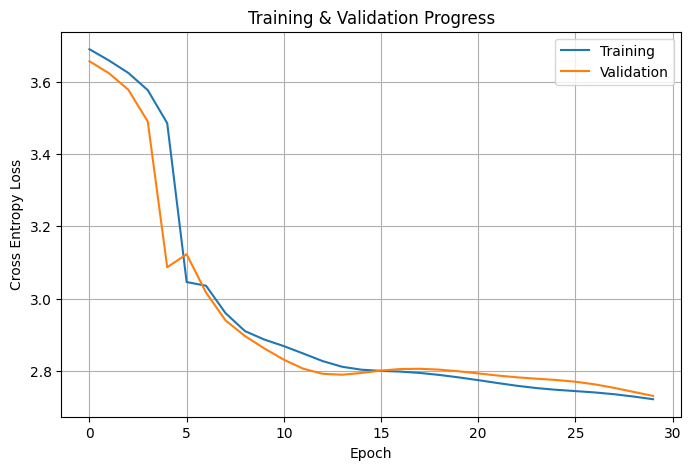

In [21]:
import matplotlib.pyplot as plt

sequence_length = 100
batch_size = 256
embedding_dim = 8
hidden_dim = 512
learning_rate = 1e-3
num_epochs = 30

########## YOUR SOLUTION HERE ##########

# Schon davor gemacht
# Alphabet und Encoder
alphabet = "abcdefghijklmnopqrstuvwxyz0123456789 .!?"  # erlaubte Zeichen
enc = Encoder(alphabet)  # Encoder-Objekt erzeugen, das Text → Zahlen umwandelt

# Schon davor gemacht
# Dataset und DataLoader 
dataset = TextDataset("text.txt", l=sequence_length)  # Datensatz-Objekt laden

# Trainings- und Validierungsaufteilung (90 % / 10 %)
train_size = int(0.9 * len(dataset))          
val_size = len(dataset) - train_size           
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])  # zufällige Aufteilung

# DataLoader erstellen (Mini-Batches generieren)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # beim Training durchmischen
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # beim Validieren Reihenfolge behalten

# Modell und Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU verwenden, falls verfügbar

# Modell erzeugen und auf GPU/CPU verschieben
model = NextCharLSTM(len(alphabet), embedding_dim, hidden_dim).to(device)

# Adam-Optimierer initialisieren, der die Modellgewichte anpasst
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Trainings- und Validierungsschleife 
best_val_loss = float("inf")   # hier merken wir uns das bisher beste Validierungs-Loss
train_loss_history = []        # speichert durchschnittliche Trainingsverluste pro Epoche
val_loss_history = []          # speichert durchschnittliche Validierungsverluste pro Epoche

# Schleife über alle Epochen
for epoch_idx in range(num_epochs):
    print(f"Epoch {epoch_idx+1}/{num_epochs}")   # Fortschritt anzeigen

    # Training 
    train_losses = epoch(train_loader, model, optimizer)   # ruft deine epoch()-Funktion mit Optimizer auf (Training)
    avg_train_loss = train_losses.mean()                   # Mittelwert über alle Mini-Batches berechnen

    # Validation 
    val_losses = epoch(val_loader, model, optimizer=None)  # ruft epoch() ohne Optimizer auf (nur Vorhersage, kein Update)
    avg_val_loss = val_losses.mean()                       # Mittelwert über alle Validierungsbatches berechnen

    # Logging 
    train_loss_history.append(avg_train_loss)              # Trainings-Loss für Plot speichern
    val_loss_history.append(avg_val_loss)                  # Validierungs-Loss für Plot speichern

    print(f"  Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")  # Ausgabe der aktuellen Werte

    # Bestes Modell speichern 
    if avg_val_loss < best_val_loss:                       # wenn Validation besser als bisher:
        best_val_loss = avg_val_loss                       # neuen besten Wert merken
        torch.save(model.state_dict(), "best_model.pt")    # Modellgewichte sichern
        print("Neues bestes Modell gespeichert.")     # Hinweis in Konsole

# Abschlussmeldung
print("\nTraining abgeschlossen.")                         # Info, dass Training fertig ist
print(f"Bestes Validierungs-Loss: {best_val_loss:.4f}")    # Bestes Ergebnis ausgeben

# Visualisierung
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Training")
plt.plot(val_loss_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Training & Validation Progress")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 6: Top-$k$ Accuracy

Write a function `topk_accuracy` that takes a list of integers $k$, a model, and a data loader and returns the top-$k$ accuracy of the model on the given data set for each $k$. A sample is considered to be classified correctly if the true label appears in the top-$k$ classes predicted by the model. Then load the best model from the previous exercise using `torch.load` and plot its top-$k$ accuracy as a function of $k$ for all possible values of $k$. Discuss the results. 

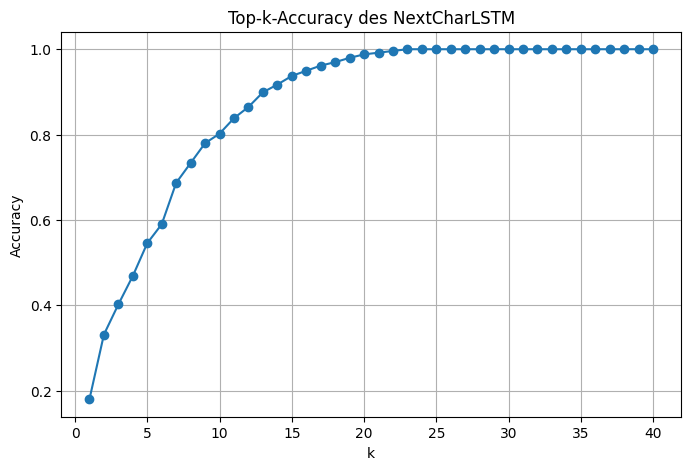

Top-1 Accuracy: 17.98%
Top-3 Accuracy: 40.20%
Top-5 Accuracy: 54.55%
Top-10 Accuracy: 80.20%


In [22]:
########## YOUR SOLUTION HERE ##########

def topk_accuracy(k_list, model, dataloader):
    """
    Berechnet die Top-k-Accuracy für alle k in k_list auf dem Datensatz im dataloader.

    Parameter:
    ----------
    k_list : list[int]
        Liste der zu prüfenden k-Werte (z. B. [1, 3, 5, 10])
    model : torch.nn.Module
        Das trainierte Modell (z. B. NextCharLSTM)
    dataloader : torch.utils.data.DataLoader
        Dataloader, der die Validierungs- oder Testdaten liefert

    Rückgabe:
    ----------
    dict[k -> float]
        Dictionary mit den Top-k-Accuracies für jeden k-Wert.
    """

    # Modell in Evaluationsmodus (kein Dropout, keine Gradienten)
    model.eval()

    # Sicherstellen, dass Modell und Daten auf dem gleichen Gerät liegen
    device = next(model.parameters()).device

    # Zähler für korrekte Vorhersagen und Gesamtanzahl
    correct_counts = {k: 0 for k in k_list}
    total = 0

    with torch.no_grad():  # Kein Backpropagation nötig
        for batch in dataloader:
            batch = batch.to(device)

            # Input: alle Zeichen außer dem letzten
            x = batch[:, :-1]
            # Ziel: alle Zeichen außer dem ersten
            y = batch[:, 1:]

            # Modellvorhersage → Logits
            logits = model(x)  # [B, L-1, alphabet_size]

            # Argmax über die Logits → Top-k-Indices
            # topk_values, topk_indices haben beide Form [B, L-1, k_max]
            max_k = max(k_list)
            _, topk_indices = torch.topk(logits, k=max_k, dim=-1)

            # y hat Form [B, L-1] → erweitern für Vergleich
            # So dass jede Zielklasse mit allen Top-k verglichen werden kann
            y_expanded = y.unsqueeze(-1).expand_as(topk_indices)

            # Für jedes k prüfen, ob das Ziel in den Top-k ist
            for k in k_list:
                correct = (topk_indices[:, :, :k] == y_expanded[:, :, :k]).any(dim=-1)
                correct_counts[k] += correct.sum().item()

            total += y.numel()  # Gesamtzahl der Zeichen

    # Accuracy pro k berechnen
    accuracies = {k: correct_counts[k] / total for k in k_list}
    return accuracies


# Beispiel

# Bestes Modell laden (aus Aufgabe 5)
best_model = NextCharLSTM(alphabet_size=40, embedding_dim=8, hidden_dim=512)
best_model.load_state_dict(torch.load("best_model.pt"))
best_model.eval()

# Datensatz vorbereiten (z. B. Validation)
val_dataset = TextDataset("text.txt", l=100)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# Top-k-Accuracies berechnen
k_values = list(range(1, 41))  # für k = 1..40 (alle möglichen Zeichen)
accuracies = topk_accuracy(k_values, best_model, val_loader)

# Visualisierung
plt.figure(figsize=(8, 5))
plt.plot(k_values, [accuracies[k] for k in k_values], marker="o")
plt.title("Top-k-Accuracy des NextCharLSTM")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Ergebnisse ausgeben
for k in [1, 3, 5, 10]:
    print(f"Top-{k} Accuracy: {accuracies[k]*100:.2f}%")

## Exercise 7: Gumbel-Max Character Sampling

In this exercise we utilize the trained network to generate novel text. To do this, take some string of seed text, which you can choose freely, and feed it to the network. For each subsequent character, the model outputs logits $z = (z_1, \dots, z_K)^\top$, where $K$ is the alphabet size. 

Use the Gumbel-Max trick to sample from the categorical distribution parameterized by 
$$
\pi_k = \frac{e^{z_k / \tau}}{\sum_{j=1}^K e^{z_j / \tau}} \quad \text{where} \quad \tau > 0 
$$
is the temperature. For $\tau \to 0$ we approach the one-hot distribution, whereas for $\tau \to \infty$ we approach the uniform distribution. The Gumbel-Max trick says that the random variable 
$$
Y = \arg \max_{k \in 1, \dots, K} (z_k / \tau + \xi_k) 
$$
follows a categorical distribution parameterized by $\pi_1, \dots, \pi_K$, where $\xi_k$ is drawn independently from the standard Gumbel distribution.

Implement next-character sampling using the Gumbel-Max trick. Try out different values of $\tau$ and see which work best. 

In [ ]:
########## YOUR SOLUTION HERE ##########

## Exercise 8: Huffman Coding using LSTM

*Thanks to Philipp Renz who had this idea.*

The Huffman code is an algorithm to compress data. It encodes symbols with different lengths depending on their frequencies. It assigns a short code to frequent symbols and a longer code to rare symbols to minimize the average code length. We provide you with an implementation that given a list of frequencies `freqs` returns a list of their respective binary codes as strings in the same order. In fact, `freqs` may contain any real numbers. 

With a model that predicts the next symbol we can achieve even shorter codes. At every time step we can use the predicted probabilities as frequencies for the Huffman code. That is, we use a new code at every time step. This code is governed by the model's belief what the next symbol will be. If the model predictions are good, we will mostly use very short codes.

First, determine the average code length per symbol on the validation set using frequencies determined on the training set. 
Then, use the prediction probabilities of your trained LSTM and determine the average code length per symbol on the validation set using an adaptable code. Add a temperature to the softmax and tune it. How many bits per symbol can you save by using the LSTM and what is the optimal temperature? 

In [ ]:
from heapq import heapify, heappop, heappush

def huffman_code(freqs):
    """This function turns a list of frequencies into a Huffman code. """
    heap = list(zip(freqs, [(i,) for i in range(len(freqs))]))
    heapify(heap)
    code = [''] * len(freqs)
    
    while len(heap) > 1:
        freq0, idx0 = heappop(heap)
        freq1, idx1 = heappop(heap)
        heappush(heap, (freq0 + freq1, idx0 + idx1))
        
        for i in idx0:
            code[i] = '0' + code[i]
        
        for i in idx1:
            code[i] = '1' + code[i]
    
    return code

########## YOUR SOLUTION HERE ##########